# 🛢️ Oil Spill Detection — MLP Classifier
**Dataset** : Sentinel-1 SAR Oil Spill Detection Dataset (Kaggle)  
**Objectif** : Entraîner un MLP sur les images SAR et comparer ses performances avec le CNN custom et ResNet.

> ⚠️ Ne pas modifier `SEED`, `ROOT_DIR`, `TRAIN_DIR`, `VAL_DIR`, `TEST_DIR`.  
> ✅ Vous pouvez ajuster `BATCH_SIZE`, `IMG_SIZE`, `NUM_EPOCHS`, `LEARNING_RATE`.


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import os
import pandas as pd
import plotly.express as px
import json
import random
import cv2
import kagglehub
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from PIL import Image
from pathlib import Path


print('Imports OK')

Imports OK


In [2]:
ROOT_DIR = Path('/root/.cache/kagglehub/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset/versions/1/data')
DATA_DIR = ROOT_DIR / 'data/'
TEST_DIR = ROOT_DIR / 'test/'
TRAIN_DIR = ROOT_DIR / 'train/'
VAL_DIR = ROOT_DIR / 'val/'


# 1) Importation des données et prétraitement

EDA à partir des fonctions de utils.py

## a) Téléchargement du dataset




In [4]:
# ════════════════════════════════════════════
# BLOC 2 — Téléchargement du dataset
# ════════════════════════════════════════════

path = kagglehub.dataset_download("harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset")
root = Path(path + "/data/S1SAR_UnBalanced_400by400_Class_")
print(f"Dataset : {root}")

Using Colab cache for faster access to the 'sentinel-1-sar-oil-spill-detection-dataset' dataset.
Dataset : /kaggle/input/sentinel-1-sar-oil-spill-detection-dataset/data/S1SAR_UnBalanced_400by400_Class_


In [81]:
# ════════════════════════════════════════════
# BLOC 3 — Liste de toutes les images
# ════════════════════════════════════════════

items = []
for label in [0, 1]:
    folder = Path(str(root) + str(label) + "/" + str(label))
    files  = sorted(folder.glob("*.jpg"))
    items += [(f, label) for f in files]

random.shuffle(items)

n0 = sum(1 for _, l in items if l == 0)
n1 = sum(1 for _, l in items if l == 1)
print(f"Classe 0 (sans huile) : {n0} images : {n0/len(items)*100:.1f} du dataset")
print(f"Classe 1 (avec huile) : {n1} images : {n1/len(items)*100:.1f} du dataset")
print(f"Total                 : {len(items)} images")

Classe 0 (sans huile) : 3725 images : 66.2 du dataset
Classe 1 (avec huile) : 1905 images : 33.8 du dataset
Total                 : 5630 images


In [91]:
import hashlib

def check_duplicates(items):
    hashes = {}
    duplicates = []

    for path, label in items:
        # Lire le contenu binaire du fichier
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hashes:
            duplicates.append((path, hashes[file_hash]))
        else:
            hashes[file_hash] = path

    if duplicates:
        print(f"⚠️ {len(duplicates)} doublons trouvés !")
        # Optionnel : afficher les deux premiers pour vérification
        for dup, orig in duplicates[:3]:
            print(f"  - {dup.name} est identique à {orig.name}")
    else:
        print("✅ Aucun doublon détecté.")

    return duplicates

dups = check_duplicates(items)


⚠️ 92 doublons trouvés !
  - 1519_1800_5600_img_bXwsAB7yjLwK2lXB_GBR_cls_0.jpg est identique à 1519_1800_5600_img_amG59V5aU3jYqKF5_GBR_cls_0.jpg
  - 1202_10400_6200_img_rBTobz78We261BWP_GBR_cls_1.jpg est identique à 1323_10400_6200_img_k0U83TqdVsM0H4va_GBR_cls_1.jpg
  - 1555_4200_5800_img_TFTd56Z6ilOTc02c_SIN_cls_1.jpg est identique à 1555_4200_5800_img_s4LuYvAocYsH6bfg_SIN_cls_1.jpg


In [92]:
# Création d'un set de hashes pour filtrer à la volée et supprimer les doublons

seen_hashes = set()
unique_items = []

for path, label in items:
    with open(path, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h not in seen_hashes:
        unique_items.append((path, label))
        seen_hashes.add(h)

items = unique_items
print(f"Nouveau total après nettoyage : {len(items)}")

Nouveau total après nettoyage : 5538


In [100]:
print(f"Classe 0 (sans huile) : {n0} images : {n0/len(items)*100:.1f} du dataset")
print(f"Classe 1 (avec huile) : {n1} images : {n1/len(items)*100:.1f} du dataset")
print(f"Total                 : {len(items)} images")

Classe 0 (sans huile) : 3725 images : 67.3 du dataset
Classe 1 (avec huile) : 1905 images : 34.4 du dataset
Total                 : 5538 images


In [93]:
# ════════════════════════════════════════════
# BLOC 4 — Chargement et normalisation
# ════════════════════════════════════════════

IMG_SIZE = (128, 128)

def load_image(path):
    """Charge une image JPG et la normalise."""
    img = Image.open(path).convert("RGB").resize(IMG_SIZE)  # resize ici
    img = np.array(img).astype(np.float32) / 255.0            # converti depuis l'image redimensionnée
    img = img.transpose(2, 0, 1)                              # (3, 128, 128)

    # Z-score par canal
    for c in range(img.shape[0]):
        mu     = img[c].mean()
        std    = img[c].std() + 1e-6
        img[c] = (img[c] - mu) / std

    return img

# Test sur une image pour vérifier
img_test, label_test = items[0]
img_array = load_image(img_test)
print(f"Shape image chargée : {img_array.shape}")
print(f"Label               : {label_test}")
print(f"Valeurs min/max     : {img_array.min():.2f} / {img_array.max():.2f}")

Shape image chargée : (3, 128, 128)
Label               : 1
Valeurs min/max     : -7.46 / 3.32


--- **description du jeu de données** ---

## b) Exploration de la composition du jeu de données
On regarde la distribution des données par classe (0 et 1), pour repérer d'éventuels déséquilibres qui pourraient affecter la performance du modèle.

**ANALYSE :**

On observe un important déséquilibre de classe, avec seulement 34% des images représentants la classe 1 (avec trace de pétrole).

Le modèle aura ainsi tendance à prédire plus fréquemment la classe 0, pour la seule raison qu'elle est plus présente dans le jeu de données, au lieu de se concentrer sur les caractéristiques propres des images de la classe 1.

Il s'agira donc de corriger ce déséquilibre de classes à l'aide d'une des méthodes suivantes :
- **Une pondération de la fonction de perte**, qui donnera ainsi artificiellement plus de poids à la classe minoritaire et moins à la classe majoritaire, corrigeant les biais induits par le déséquilibre.
- **Le Sampler** : au lieu de pondérer la fonction de poids, le sampler va affecter le DataLoader, en le forçant à piocher plus souvent dans la classe minoritaire pour compenser.


Enfin, en présence d'un déséquilibre de classes, **l'utilisation de métriques d'évaluation robustes** est importante. En effet, utiliser uniquement l'accuracy ne sera pas suffisant car un modèle fainéant, prédisant les classes selon leur pourcentage de présence dans le dataset, peut avoir une bonne accuracy. Il faudra ainsi aussi utiliser le recall et la précision pour évaluer plus finement la capacité du modèle à reconnaître des images d'une classe majoritaire ou minoritaire.



## c) Création des jeux d'entraienement, de validation et de test

On divise le jeu de données en trois ensembles distinct :
- **Le jeu d'entraînement**

Le jeu d'entraînement constitue la base de connaissances du modèle. C'est sur cet ensemble que l'algorithme de rétropropagation (backpropagation) ajuste les poids du réseau de neurones.

- **Le jeu de validation**

Le jeu de validation oriente le choix des hyperparamètres (taux d'apprentissage, nombre d'époques) pendant la phase d'apprentissage. Contrairement au jeu d'entraînement, le modèle ne "voit" pas ces données pour ajuster ses poids, mais elles sont utilisées pour évaluer ses performances à la fin de chaque époque.

- **Le jeu de test**

Le jeu de test représente l'évaluation finale et impartiale du système. Il simule le déploiement du modèle sur des données réelles et totalement inconnues.



# 2. Encodage des labels & Normalisation

In [94]:
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 3e-4
EPOCHS = 80
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

In [95]:
# ════════════════════════════════════════════
# BLOC 6 — Découpage train / val / test
# ════════════════════════════════════════════

print("Préparation des données en mémoire...")
X_list = []
y_list = []

for path, label in items:
    X_list.append(load_image(path))
    y_list.append(label)

X = torch.tensor(np.array(X_list))
y = torch.tensor(y_list).long()

dataset = TensorDataset(X, y)

n_total = len(dataset)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train : {n_train} | Val : {n_val} | Test : {n_test}")
print(f"Vérification : {X.shape}")

train_ds = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds  = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Préparation des données en mémoire...
Train : 3878 | Val : 830 | Test : 830
Vérification : torch.Size([5538, 3, 128, 128])


La plupart des modèles demandent des données préalablement converties en *tensors* (vecteurs à plus de 2 dimensions), et *normalisées* pour fluidifier et alléger leur traitement.

# 3. Implémentation du modèle de MLP

Un **perceptron multicouche (MLP)** est un type de réseau neuronal artificiel composé de plusieurs couches de neurones. Les neurones du MLP utilisent généralement des fonctions d'activation non linéaires, ce qui permet au réseau d'apprendre des schémas complexes dans les données. Les MLP jouent un rôle important dans l'apprentissage automatique car elles peuvent apprendre des relations non linéaires dans les données, ce qui en fait des modèles puissants pour des tâches telles que la classification, la régression et la reconnaissance des formes.

Le perceptron multicouche va accepter en données d'entrées des images convertis en tensor : une suite de chiffre qui traduit l'information contenue dans les pixels de l'image. Elle va analyser ces données à l'aide de différentes couches de neurones pour identifier des schémas et caractéristiques et chercher ainsi à prédire leur label.

Cependant, la transformation initiale des donénes isole les caractéristiques de l'image dans l'espace : les pixels sont analysés sans prendre en compte ceux qui les entourent. Ainsi, si le MLP a constitué une révolution dans le monde du machine learning, il n'en reste pas moins aujourd'hui l'un des modèles les moins performants pour analyser des images complexes.

Nous allons néanmoins commencer par vérifier la qualité des résultats issus du MLP, d'après le principe de parcimonie qui veut qu'on cherche à obtenir des résultats satisfaisant à l'aide du modèle le plus simple et le plus économe possible. Nous choisissons donc de tester ce modèle avant de nous tourner, si besoin, vers des modèles plus complexes comme le CNN.


## a) Architecture du modèle


On commence par définir l'achitecture du modèle, qui comprend les couches et le passage des données.

On crée un objet qui hérite de la classe nn.Module.

A partir de cette classe, on définit nos différentes couches de neurones denses : 4 pour ce modèle. Les couches vont identifier des caractéristiques de plus en plus abstraites sur l'image, et finir par lui assigner une classe à la sortie.



In [121]:
# hyperparamètres modèle

dropout = 0.3 #tests 4,5 = 0.5

# paramètres couches linéaires
a = 1024  #test 1 = 1024,   2 = 512,    2,5,6,7 = 1024,
b = 512   #test 1 = 512,    2 = 256,    2,5,6,7 = 512,
c = 256   #test 1 = 256,    2 = 128,    4,5,6,7 = 256,

In [113]:
import torch.nn as nn
import torch.nn.functional as F


class MLP(nn.Module):
    def __init__(self, IMG_SIZE, num_classes, dropout_rate=dropout):
        super(MLP, self).__init__()
        # Définition des couches linéaires
        self.fc1 = nn.Linear(IMG_SIZE, a)
        self.fc2 = nn.Linear(a, b)
        self.fc3 = nn.Linear(b, c)
        self.fc4 = nn.Linear(c, num_classes)

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        # On aplatit le tensor de l'image
        x = x.view(x.size(0), -1)

        # Passages avec activation ReLU
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)

        # Pas de ReLU sur la dernière couche (la Logit)
        x = self.fc4(x)
        return x

# --- CALCUL DES PARAMÈTRES --- #

# On multiplie les dimensions pour obtenir le nombre total de neurones d'entrée
input_total_size = IMG_SIZE[0] * IMG_SIZE[1] * 3 #1 si en noir et blanc, 3 si couleurs
CLASS_NAMES = 2 #2 : nombre de sorties possibles

# Initialisation correcte
model_mlp = MLP(input_total_size, CLASS_NAMES)


Configuration de l'optimiseur.

L'optimiseur va orienter la correction des poids par le modèle à partir du gradient calculé.

Nous avons, comme souvent en deep learning, choisi d'utiliser l'optimiseur Adam, qui présente deux avantages :

- il garde une mémoire de la direction qu'il avait prise auparavant, ce qui lui permet d'accélérer si la tendance de modification des poids se confirme

- Il adapte le rythme d'apprentissage par paramètre, en augmentant celui des neurones très lents, et en diminuant ceux des neurones très rapides.

In [122]:
# adam + alpha (weight_decay) + learning_rate_init
optimizer = torch.optim.Adam(
    model_mlp.parameters(),
    lr=LEARNING_RATE,  #LR retenu = celui ocnventionnellement choisi pour Adam
    weight_decay=1e-4  #éviter l'overfitting en tirant un peu les poids vers 0
)


Création d'une fonction de perte pondérée pour prendre en compte le déséquilibre de classe. La classe 0 a ainsi un poids de 1, tandis que la classe 1, deux fois moins présente, voit son poids doubler.

In [123]:
# La fonction de perte pour la classification, pondérée pour corriger le déséquilibre de classe
# Calcul des poids (inversement proportionnels à la fréquence)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = torch.tensor([0.344, 0.673], dtype=torch.float).to(device)

# On passe les poids au critère
criterion = nn.CrossEntropyLoss(weight=weights)

Définition d'un *Scheduler* (programmateur), qui adapte l'entraînement. Son rôle est de surveiller la progression du modèle et d'ajuster automatiquement la vitesse d'apprentissage si le modèle commence à stagner.

In [124]:
# Équivalent de learning_rate='adaptive'
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.1
)

In [132]:
# Data augmentation

from torch.utils.data import DataLoader, Subset
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.05), #tests 3,4 = 5,    test 5 = 2,   test 6,7 = 0.05
    transforms.RandomVerticalFlip(p=0.05),   #tests 3,4 = 5,    test 5 = 2,   test 6,7 = 0.05
    transforms.RandomRotation(20),          # test 3 = activé, tests 4,5,6 = désactivé
])

## b) Entraînement

In [133]:
import torchmetrics
from torchmetrics import Precision, Recall, Accuracy


# task="multiclass" car on a num_classes=2
precision_fn = Precision(task="binary", num_classes=2).to(device)
recall_fn = Recall(task="binary", num_classes=2).to(device)
accuracy_fn = Accuracy(task="binary", num_classes=2).to(device)


def train_model(model_mlp, train_ds, val_ds, optimizer, scheduler, criterion, epochs=EPOCHS):
    model = model_mlp.to(device)
    # Plus besoin de redéfinir criterion, optimizer ou scheduler ici
    # car ils sont passés en arguments

    history = {"train_loss": [], "train_accuracy": [], "train_precision": [], "train_recall": [],
            "val_loss": [], "val_accuracy": [], "val_precision": [], "val_recall": []}

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        train_loss_sum = 0
        accuracy_fn.reset(); precision_fn.reset(); recall_fn.reset()

        for images, labels in train_ds:
            images, labels = images.to(device), labels.to(device)

            # Augmentation de données (tests 3, 4, 5, 6 et 7)
            images = train_transform(images)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_loss_sum += loss.item() * len(images)
            accuracy_fn.update(preds, labels)
            precision_fn.update(preds, labels)
            recall_fn.update(preds, labels)

        history['train_loss'].append(train_loss_sum / len(train_ds.dataset))
        history['train_accuracy'].append(accuracy_fn.compute().item())
        history['train_precision'].append(precision_fn.compute().item())
        history['train_recall'].append(recall_fn.compute().item())

        # --- VALIDATION ---
        model.eval()
        val_loss_sum = 0
        accuracy_fn.reset(); precision_fn.reset(); recall_fn.reset()

        with torch.no_grad():
            for images, labels in val_ds:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss_sum += loss.item() * len(images)
                accuracy_fn.update(preds, labels)
                precision_fn.update(preds, labels)
                recall_fn.update(preds, labels)

            epoch_val_loss = val_loss_sum / len(val_ds.dataset)

            # MISE À JOUR DU SCHEDULER
            scheduler.step(epoch_val_loss)

            history['val_loss'].append(epoch_val_loss)
            history['val_accuracy'].append(accuracy_fn.compute().item())
            history['val_precision'].append(precision_fn.compute().item())
            history['val_recall'].append(recall_fn.compute().item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} — "
                  f"Loss: {history['train_loss'][-1]:.4f}, Acc: {history['train_accuracy'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_accuracy'][-1]:.4f}")

    return history

In [131]:
# Entraînement
history = train_model(
    model_mlp = model_mlp,
    train_ds = train_ds,
    val_ds = val_ds,
    optimizer = optimizer,
    scheduler = scheduler,
    criterion = criterion,
    epochs = EPOCHS
)

Epoch 1/80 — Loss: 0.4735, Acc: 0.7849 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 10/80 — Loss: 0.4521, Acc: 0.8071 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 20/80 — Loss: 0.4678, Acc: 0.8002 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 30/80 — Loss: 0.4492, Acc: 0.8056 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 40/80 — Loss: 0.4607, Acc: 0.7940 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 50/80 — Loss: 0.4499, Acc: 0.7991 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 60/80 — Loss: 0.4634, Acc: 0.8017 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 70/80 — Loss: 0.4551, Acc: 0.8032 | Val Loss: 0.5798, Val Acc: 0.7386
Epoch 80/80 — Loss: 0.4692, Acc: 0.7865 | Val Loss: 0.5798, Val Acc: 0.7386


## 8. Historique des résultats

### a) Essai 1 : surapprentissage

Paramètres :
- EPOCH = 80,
- WEIGHT_DC = 1e-4
- DROPOUT = 0.3
- Complexité des couches de neurones : 1024, 512, 256


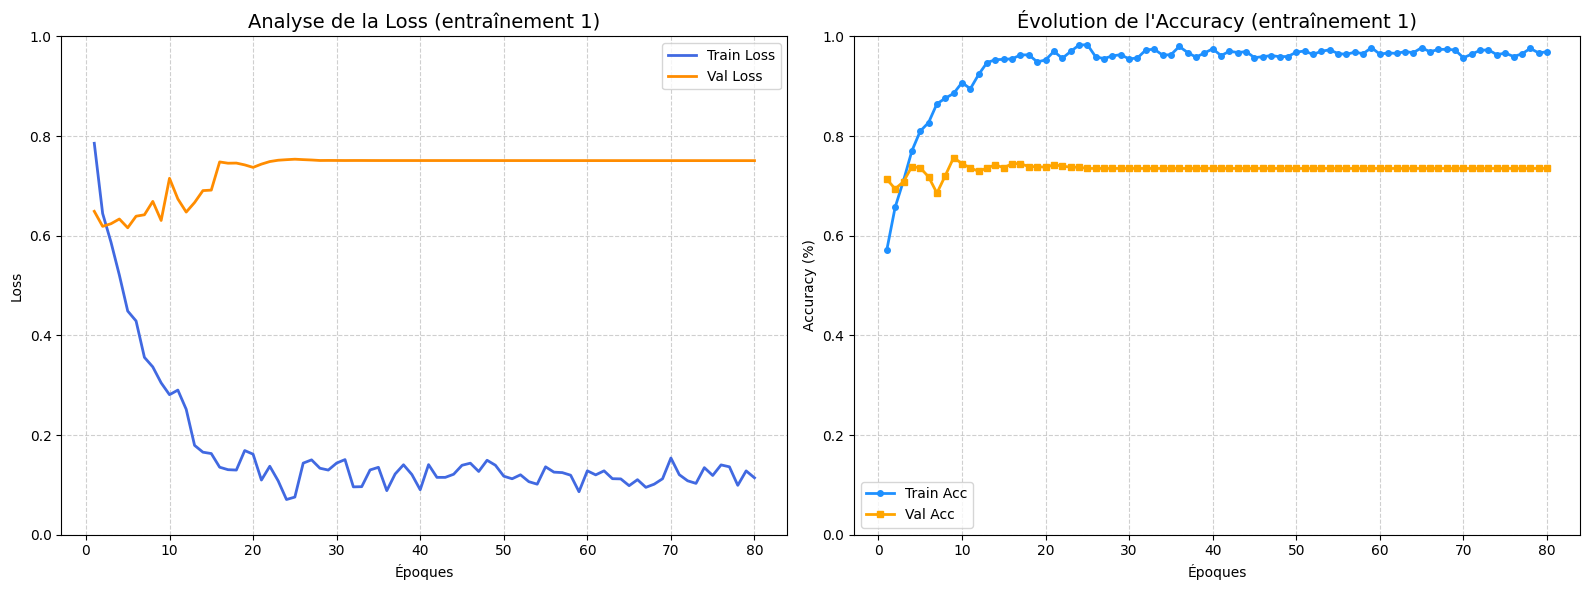

In [111]:
# @title
import matplotlib.pyplot as plt

# Création d'une figure avec deux zones (1 ligne, 2 colonnes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, len(history['train_loss']) + 1)

# --- GRAPHIQUE 1 : LOSS (PERTE) ---
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2, markersize=4)
ax1.plot(epochs, history['val_loss'], label='Val Loss', color='darkorange', linewidth=2, markersize=4)

ax1.set_title("Analyse de la Loss (entraînement 1)", fontsize=14)
ax1.set_xlabel("Époques")
ax1.set_ylabel("Loss")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRAPHIQUE 2 : ACCURACY (EXACTITUDE) ---
ax2.plot(epochs, history['train_accuracy'], label='Train Acc', color='dodgerblue', linewidth=2, marker='o', markersize=4)
ax2.plot(epochs, history['val_accuracy'], label='Val Acc', color='orange', linewidth=2, marker='s', markersize=4)

ax2.set_title("Évolution de l'Accuracy (entraînement 1)", fontsize=14)
ax2.set_xlabel("Époques")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0,1)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



Lors des premiers test, on observe un fort surapprentissage du modèle : sur 10 et sur 80 époques, le score de perte du jeu d'entraînement se réduit fortement tandis que celui du jeu d'évaluation ne cesse d'augmenter (finit aux alentours de 1). On met alors 3 mesures en place pour limiter le surapprentissage.
1) On augmente le dropout de 0,3 à 0,5.
2) On augmente le learning rate de 1e-4 à 1e-3 pour qu'il pénalise plus fortement les poids qui prennent rapidement de la confiance
3) On réduit la complexité dans les couches, pour forcer le modèle à se concentrer sur l'essentiel.

### b) Essai 2 : légère amélioration
- EPOCH = 80,
- WEIGHT_DC = 1e-3,
- DROPOUT = 0.5,
- Complexité des couches de neurones : 512, 256, 128

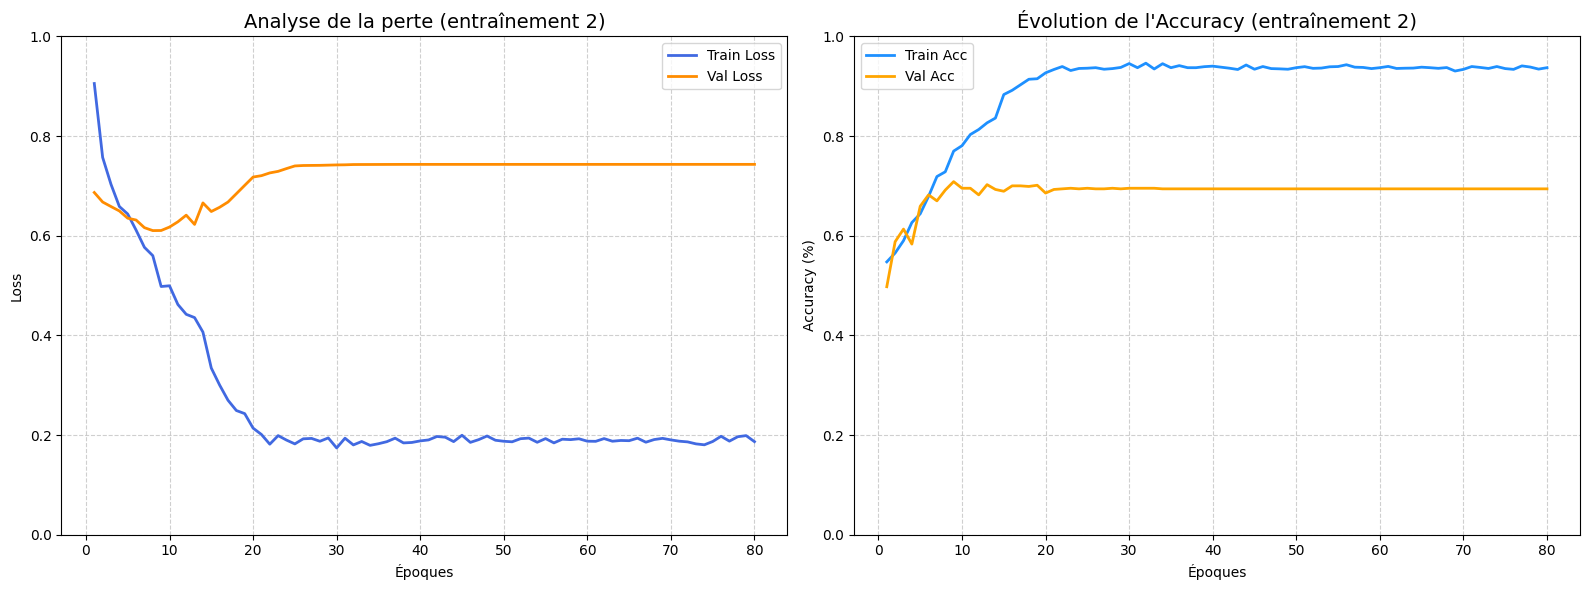

In [120]:
# @title
import matplotlib.pyplot as plt

# Création d'une figure avec deux zones (1 ligne, 2 colonnes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, len(history['train_loss']) + 1)

# --- GRAPHIQUE 1 : LOSS ---
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2, markersize=4)
ax1.plot(epochs, history['val_loss'], label='Val Loss', color='darkorange', linewidth=2, markersize=4)

ax1.set_title("Analyse de la perte (entraînement 2)", fontsize=14)
ax1.set_xlabel("Époques")
ax1.set_ylabel("Loss")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRAPHIQUE 2 : ACCURACY  ---
ax2.plot(epochs, history['train_accuracy'], label='Train Acc', color='dodgerblue', linewidth=2, markersize=4)
ax2.plot(epochs, history['val_accuracy'], label='Val Acc', color='orange', linewidth=2, markersize=4)

ax2.set_title("Évolution de l'Accuracy (entraînement 2)", fontsize=14)
ax2.set_xlabel("Époques")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0,1)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Faible amélioration : on décide d'essayer la méthode de la data augmentation pour présenter des images différentes au modèle lors de l'entraînement, et éviter l'overfitting.

### c) Essai 3 à 6

**ESSAI 3 :** On observe que les hyperparamètres du test 2 associés à la data augmentation provoquaient une diminution très lente de la loss, à la fois pour train et val.

**ESSAI 4 :** On tente donc avec les hyperparamètres du 1 et la data augmentation --> le modèle n'apprends plus. Les loss stagnent à 0,6.

**ESSAI 5 :** On allège la data augmentation pour que le modèle arrive à apprendre un peu des images : suppression de la rotation, on garde les horizontal et vertical flips --> le sous apprentissage persiste, malgré un abaissement des horizontal et vertical flips à 2.

**ESSAI 6 :** On essaie de supprimer les poids du criterion et on obtient toujours une stagnation autour de 0.6.

**ESSAI 7:** On remet donc les poids du criterion, avec une faible transformation des données (Horizontal et Vertical flips à 0.5, Rotation à 0.15) et les paramètres du premier test, et on visualise ce dernier essai :

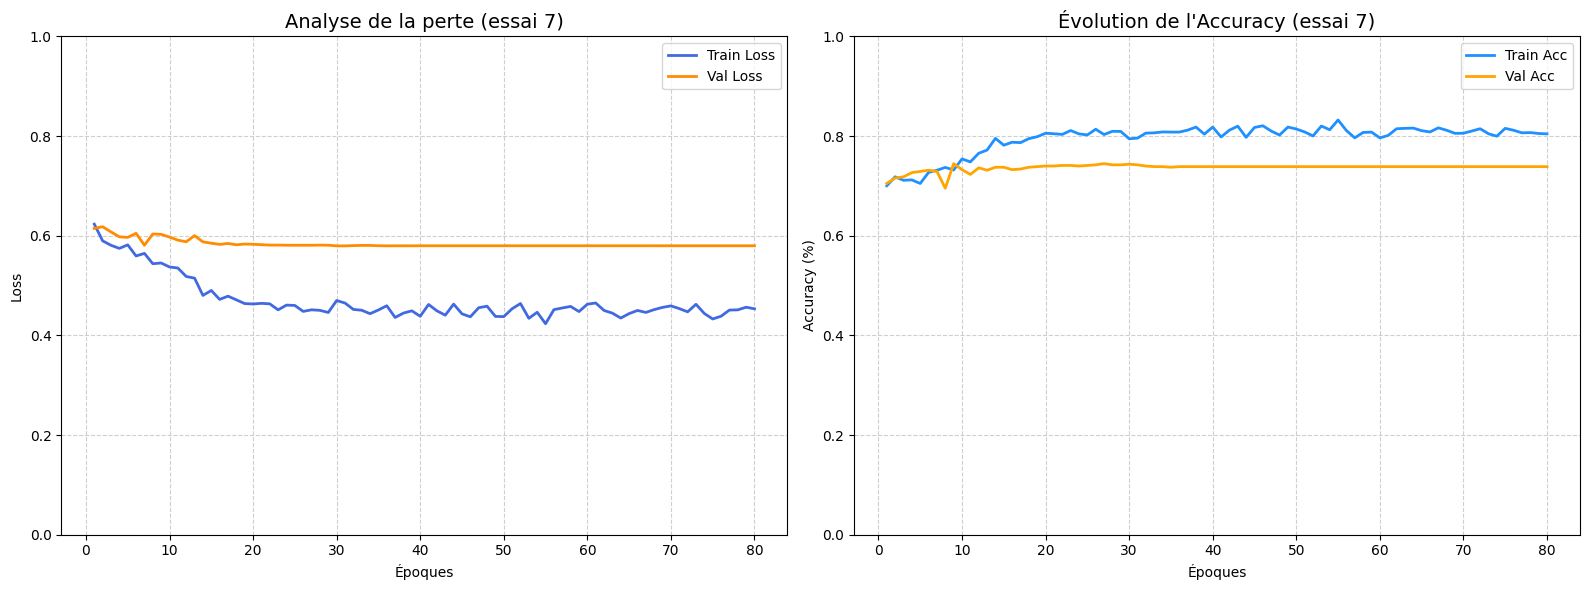

In [129]:
import matplotlib.pyplot as plt

# Création d'une figure avec deux zones (1 ligne, 2 colonnes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, len(history['train_loss']) + 1)

# --- GRAPHIQUE 1 : LOSS (PERTE) ---
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2, markersize=4)
ax1.plot(epochs, history['val_loss'], label='Val Loss', color='darkorange', linewidth=2, markersize=4)

ax1.set_title("Analyse de la perte (essai 7)", fontsize=14)
ax1.set_xlabel("Époques")
ax1.set_ylabel("Loss")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRAPHIQUE 2 : ACCURACY (EXACTITUDE) ---
ax2.plot(epochs, history['train_accuracy'], label='Train Acc', color='dodgerblue', linewidth=2, markersize=4)
ax2.plot(epochs, history['val_accuracy'], label='Val Acc', color='orange', linewidth=2, markersize=4)

ax2.set_title("Évolution de l'Accuracy (essai 7)", fontsize=14)
ax2.set_xlabel("Époques")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0,1)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

À la fin de l'essai 6, on observe une stagnation de la perte, et surtout de l'accuracy, à un niveau équivalent à la distribution des images par catégories (autour de 66%) pour les jeux d'entraînement et d'évaluation. **Il semblerait donc que le modèle parie sur la bonne réponse plutôt qu'il n'analyse les images.**

Vu l'absence de progrès avec la complexification des neurones entre les tests 3 et 4, complexifier le modèle avec des couches supplémentaires n'apparaît pas comme une option pertinente.

Malgré nos essais, nous ne sommes pas parvenus à faire apprendre les caractéristiques de nos données au modèle MLP. Cela peut s'expliquer par la nature même d'un modèle perceptron multicouche,
- Qui lit les images à plat, sans prendre en compte la proximité des pixels entre eux
- Qui ne hiérachise pas les caractéristiques (contrairement aux CNN)
- La lourdeur induite par les couches denses et le grand nombre de paramètres.


Le meilleur résultat obtenu était à l'essai 2 (pas d'augmentation de données, modèle simplifié), ou la perte du jeu d'évaluation est passée sous 0,6 lors de la onzième époque.